In [1]:
!pip install -q transformers anthropic matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.6 MB/s eta 0:00:00


In [2]:
import numpy as np

import matplotlib.pyplot as plt

In [3]:

from transformers import AutoTokenizer



tokenizer = AutoTokenizer.from_pretrained("gpt2")



words = ["unbelievable", "the", "internationalization", "Transformer", "CGI", "tokenization"]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
for w in words:

    ids = tokenizer.encode(w)

    pieces = [tokenizer.decode([i]) for i in ids]

    print(f"{w:24s} -> {pieces}  ({len(ids)} token{'s' if len(ids)!=1 else ''})")

unbelievable             -> ['un', 'bel', 'iev', 'able']  (4 tokens)
the                      -> ['the']  (1 token)
internationalization     -> ['international', 'ization']  (2 tokens)
Transformer              -> ['Trans', 'former']  (2 tokens)
CGI                      -> ['C', 'GI']  (2 tokens)
tokenization             -> ['token', 'ization']  (2 tokens)


In [5]:

from transformers import AutoModel

import torch



model = AutoModel.from_pretrained("gpt2")

embedding_table = model.get_input_embeddings().weight.detach().numpy()  # shape: (vocab_size, hidden_dim)

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [6]:
def word_vector(word):

    # Use the first token of the word's encoding as a stand-in single-token vector

    token_id = tokenizer.encode(" " + word)[0]

    return embedding_table[token_id]



sample_words = ["king", "queen", "man", "woman", "dog", "cat", "Python", "JavaScript"]

vectors = np.array([word_vector(w) for w in sample_words])

In [7]:

def cosine_sim(a, b):

    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))



n = len(sample_words)

sim_matrix = np.zeros((n, n))

for i in range(n):

    for j in range(n):

        sim_matrix[i, j] = cosine_sim(vectors[i], vectors[j])

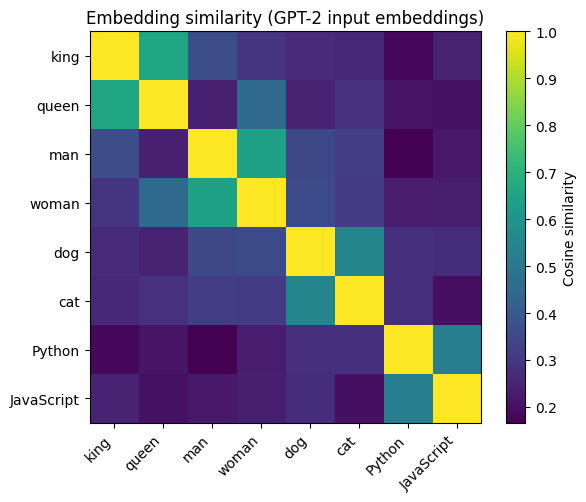

In [8]:
plt.figure(figsize=(6, 5))

plt.imshow(sim_matrix, cmap="viridis")

plt.xticks(range(n), sample_words, rotation=45, ha="right")

plt.yticks(range(n), sample_words)

plt.colorbar(label="Cosine similarity")

plt.title("Embedding similarity (GPT-2 input embeddings)")

plt.tight_layout()

plt.show()